# **Human Activity Recognition using a Hidden Markov Model**
# Group Name: **HMM Group 39**
### Members: **Terry Manzi & Limpho Elizabeth Semakale**

### This is an implementation an HMM-based classification system for recognizing human activities (jumping, standing, still, walking) from smartphone accelerometer and gyroscope sensor data.

## Workflow:
1. **Data Loading**: Load sensor data from Google Drive or in /data
2. **Preprocessing**: Resample and window the time-series data
3. **Feature Extraction**: Compute time and frequency domain features
4. **HMM Training**: Train Gaussian HMMs using Baum-Welch algorithm
5. **Viterbi Decoding**: Decode hidden states from test sequences
6. **Evaluation**: Compute metrics and visualize results


## Installing Dependencies & Importing Libraries

Install required packages and import all necessary libraries for signal processing, machine learning, and visualization.

In [33]:
# Install required packages
!pip install -q hmmlearn scipy scikit-learn seaborn

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path

# Signal processing
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# HMM
from hmmlearn import hmm

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Mount Google Drive & Load Data

Mount Google Drive and load all accelerometer and gyroscope CSV files. The data structure:
- 4 activity classes: jumping, standing, still, walking
- Two sensor types: accelerometer (acc) and gyroscope (gyro)
- Each CSV contains x, y, z columns and timestamps

In [34]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/HMM_ML_Techniques_2/data'  # Adjust to your Drive path


# For local development, use relative path
# DATA_PATH = '../data'

# Activity classes
ACTIVITIES = ['jumping', 'standing', 'still', 'walking']

def load_sensor_data(data_path):
    """
    Load all sensor CSV files and return a consolidated DataFrame.
    CSV structure:
    - Accelerometer: time, ax, ay, az, atotal
    - Gyroscope: time, gx, gy, gz
    """
    all_data = []
    summary = []

    for activity in ACTIVITIES:
        activity_path = os.path.join(data_path, activity)
        if not os.path.exists(activity_path):
            print(f"Warning: {activity_path} not found, skipping...")
            continue

        # Get all CSV files
        csv_files = [f for f in os.listdir(activity_path) if f.endswith('.csv')]
        acc_files = sorted([f for f in csv_files if f.startswith('acc_')])
        gyro_files = sorted([f for f in csv_files if f.startswith('gyro_')])

        activity_data = []

        for acc_file in acc_files:
            # Load accelerometer data (columns: time, ax, ay, az, atotal)
            acc_df = pd.read_csv(os.path.join(activity_path, acc_file))
            acc_df['sensor'] = 'acc'
            acc_df['label'] = activity
            acc_df['file_id'] = acc_file

            # Keep only needed columns: time, ax, ay, az
            acc_df = acc_df[['time', 'ax', 'ay', 'az', 'sensor', 'label', 'file_id']].copy()

            # Try to find matching gyro file
            file_num = acc_file.split('_')[-1].replace('.csv', '')
            gyro_file = f'gyro_{activity}_{file_num}.csv'

            if gyro_file in gyro_files:
                # Load matching gyroscope data (columns: time, gx, gy, gz)
                gyro_df = pd.read_csv(os.path.join(activity_path, gyro_file))

                # Merge on time (using nearest time stamps)
                merged = pd.merge_asof(
                    acc_df.sort_values('time'),
                    gyro_df[['time', 'gx', 'gy', 'gz']].sort_values('time'),
                    on='time',
                    direction='nearest',
                    tolerance=0.05  # 50ms tolerance
                )
            else:
                # No gyro file - fill with zeros
                merged = acc_df.copy()
                merged['gx'] = 0.0
                merged['gy'] = 0.0
                merged['gz'] = 0.0

            # Fill any NaN values in gyro columns with 0
            for col in ['gx', 'gy', 'gz']:
                if col in merged.columns:
                    merged[col] = merged[col].fillna(0.0)

            activity_data.append(merged)

        if activity_data:
            activity_df = pd.concat(activity_data, ignore_index=True)
            all_data.append(activity_df)
            summary.append({
                'Activity': activity,
                'Num Files': len(acc_files),
                'Total Rows': len(activity_df),
                'Has Gyro': len(gyro_files) > 0
            })

    # Combine all data
    df_all = pd.concat(all_data, ignore_index=True)
    df_summary = pd.DataFrame(summary)

    return df_all, df_summary

# Load data
print("Loading sensor data...")
df_data, df_summary = load_sensor_data(DATA_PATH)

# Display summary
print("\n=== Data Summary ===")
print(df_summary.to_string(index=False))
print(f"\nTotal samples loaded: {len(df_data):,}")
print(f"Features: {[col for col in df_data.columns if col in ['ax', 'ay', 'az', 'gx', 'gy', 'gz']]}")
print(f"\nLabel distribution:")
print(df_data['label'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading sensor data...

=== Data Summary ===
Activity  Num Files  Total Rows  Has Gyro
 jumping          8        6352      True
standing         11        9675     False
   still         11       10767      True
 walking          8        7011      True

Total samples loaded: 33,805
Features: ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

Label distribution:
label
still       10767
standing     9675
walking      7011
jumping      6352
Name: count, dtype: int64


## Preprocessing & Windowing

Resample data to a common sampling rate (50 Hz) and apply sliding window segmentation:
- Window size: 100 samples (2 seconds at 50 Hz)
- Overlap: 50% (50 samples)
- Each window is labeled with its activity class

In [35]:
# Configuration
TARGET_SAMPLE_RATE = 50  # Hz
WINDOW_SIZE = 100  # samples
OVERLAP = 50  # samples (50% overlap)
STEP_SIZE = WINDOW_SIZE - OVERLAP

def resample_data(df, file_col='file_id', target_rate=50):
    """
    Resample each recording to a target sampling rate.
    """
    resampled_data = []

    for file_id in df[file_col].unique():
        file_df = df[df[file_col] == file_id].copy()

        # Use 'time' column from CSV
        time = file_df['time'].values

        # Normalize time to start at 0
        time = time - time[0]

        # Create new time grid at target rate
        duration = time[-1]
        new_time = np.arange(0, duration, 1.0 / target_rate)

        # Interpolate each sensor axis
        sensor_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        resampled = {'file_id': file_id, 'label': file_df['label'].iloc[0]}

        for col in sensor_cols:
            if col in file_df.columns and len(file_df) > 1:
                # Linear interpolation
                f = interp1d(time, file_df[col].values, kind='linear',
                           bounds_error=False, fill_value='extrapolate')
                resampled[col] = f(new_time)
            else:
                # If a sensor column is missing, fill with zeros
                resampled[col] = np.zeros(len(new_time))

        # Create DataFrame for this file
        file_resampled = pd.DataFrame({
            'time': new_time,
            **{col: resampled[col] for col in sensor_cols},
            'file_id': file_id,
            'label': file_df['label'].iloc[0]
        })

        resampled_data.append(file_resampled)

    return pd.concat(resampled_data, ignore_index=True)

def create_windows(df, window_size=100, step_size=50):
    """
    Create sliding windows from the resampled data.
    """
    windows = []
    labels = []
    file_ids = []

    for file_id in df['file_id'].unique():
        file_df = df[df['file_id'] == file_id]
        label = file_df['label'].iloc[0]

        # Extract sensor columns
        sensor_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        data = file_df[sensor_cols].values

        # Create windows
        num_windows = (len(data) - window_size) // step_size + 1

        for i in range(num_windows):
            start_idx = i * step_size
            end_idx = start_idx + window_size

            if end_idx <= len(data):
                window = data[start_idx:end_idx]
                windows.append(window)
                labels.append(label)
                file_ids.append(file_id)

    return np.array(windows), np.array(labels), np.array(file_ids)

# Resample data
print("Resampling data to {} Hz...".format(TARGET_SAMPLE_RATE))
df_resampled = resample_data(df_data)

print(f"Resampled data shape: {df_resampled.shape}")
print(f"Total duration: ~{len(df_resampled) / TARGET_SAMPLE_RATE:.1f} seconds")

# Create windows
print(f"\nCreating windows (size={WINDOW_SIZE}, overlap={OVERLAP})...")
windows, window_labels, window_files = create_windows(
    df_resampled,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE
)

print(f"Created {len(windows):,} windows")
print(f"Window shape: {windows.shape} (num_windows, window_size, num_sensors)")
print(f"\nWindows per activity:")
for activity in ACTIVITIES:
    count = np.sum(window_labels == activity)
    print(f"  {activity:>10}: {count:>5} windows")

Resampling data to 50 Hz...
Resampled data shape: (17018, 9)
Total duration: ~340.4 seconds

Creating windows (size=100, overlap=50)...
Created 286 windows
Window shape: (286, 100, 6) (num_windows, window_size, num_sensors)

Windows per activity:
     jumping:    52 windows
    standing:    82 windows
       still:    93 windows
     walking:    59 windows


## Feature Extraction

Extract time-domain and frequency-domain features from each window:

**Time-domain features (per axis):**
- Mean, Variance, Std, Min, Max, Range
- Signal Magnitude Area (SMA)
- Correlation between axes

**Frequency-domain features (per axis):**
- Dominant frequency
- Spectral energy
- Top 3 FFT magnitudes

In [36]:
def extract_time_features(window):
    """
    Extract time-domain features from a single window.
    window shape: (time_steps, 6) where 6 = [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
    """
    features = []

    # Process each axis
    for axis_idx in range(window.shape[1]):
        signal = window[:, axis_idx]

        # Basic statistics
        features.extend([
            np.mean(signal),
            np.var(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.max(signal) - np.min(signal),  # Range
        ])

    # Signal Magnitude Area for each sensor
    # Accelerometer SMA
    acc_sma = np.mean(np.abs(window[:, 0]) + np.abs(window[:, 1]) + np.abs(window[:, 2]))
    features.append(acc_sma)

    # Gyroscope SMA
    gyro_sma = np.mean(np.abs(window[:, 3]) + np.abs(window[:, 4]) + np.abs(window[:, 5]))
    features.append(gyro_sma)

    # Correlation features - accelerometer axes
    if np.std(window[:, 0]) > 0 and np.std(window[:, 1]) > 0:
        corr_xy = np.corrcoef(window[:, 0], window[:, 1])[0, 1]
    else:
        corr_xy = 0

    if np.std(window[:, 0]) > 0 and np.std(window[:, 2]) > 0:
        corr_xz = np.corrcoef(window[:, 0], window[:, 2])[0, 1]
    else:
        corr_xz = 0

    if np.std(window[:, 1]) > 0 and np.std(window[:, 2]) > 0:
        corr_yz = np.corrcoef(window[:, 1], window[:, 2])[0, 1]
    else:
        corr_yz = 0

    features.extend([corr_xy, corr_xz, corr_yz])

    # Correlation features - gyroscope axes
    if np.std(window[:, 3]) > 0 and np.std(window[:, 4]) > 0:
        corr_gxy = np.corrcoef(window[:, 3], window[:, 4])[0, 1]
    else:
        corr_gxy = 0

    if np.std(window[:, 3]) > 0 and np.std(window[:, 5]) > 0:
        corr_gxz = np.corrcoef(window[:, 3], window[:, 5])[0, 1]
    else:
        corr_gxz = 0

    if np.std(window[:, 4]) > 0 and np.std(window[:, 5]) > 0:
        corr_gyz = np.corrcoef(window[:, 4], window[:, 5])[0, 1]
    else:
        corr_gyz = 0

    features.extend([corr_gxy, corr_gxz, corr_gyz])

    return features

def extract_frequency_features(window, sample_rate=50):
    """
    Extract frequency-domain features using FFT.
    """
    features = []

    # Process each axis
    for axis_idx in range(window.shape[1]):
        signal = window[:, axis_idx]

        # Compute FFT
        fft_values = fft(signal)
        fft_magnitude = np.abs(fft_values[:len(fft_values)//2])  # Take positive frequencies
        freqs = fftfreq(len(signal), 1/sample_rate)[:len(fft_values)//2]

        # Dominant frequency
        if len(fft_magnitude) > 0:
            dom_freq_idx = np.argmax(fft_magnitude)
            dom_freq = freqs[dom_freq_idx]
        else:
            dom_freq = 0

        # Spectral energy
        spectral_energy = np.sum(fft_magnitude ** 2)

        # Top 3 FFT magnitudes
        top3_indices = np.argsort(fft_magnitude)[-3:][::-1]
        top3_mags = fft_magnitude[top3_indices]

        features.extend([
            dom_freq,
            spectral_energy,
            top3_mags[0] if len(top3_mags) > 0 else 0,
            top3_mags[1] if len(top3_mags) > 1 else 0,
            top3_mags[2] if len(top3_mags) > 2 else 0,
        ])

    return features

def extract_all_features(windows, sample_rate=50):
    """
    Extract all features from all windows.
    """
    all_features = []

    for i, window in enumerate(windows):
        # Time-domain features
        time_feats = extract_time_features(window)

        # Frequency-domain features
        freq_feats = extract_frequency_features(window, sample_rate)

        # Combine
        all_feats = time_feats + freq_feats
        all_features.append(all_feats)

        if (i + 1) % 500 == 0:
            print(f"Processed {i+1}/{len(windows)} windows...")

    return np.array(all_features)

# Extract features
print("Extracting features from windows...")
X_features = extract_all_features(windows, sample_rate=TARGET_SAMPLE_RATE)
y_labels = window_labels

print(f"\n=== Feature Extraction Complete ===")
print(f"Feature matrix shape: {X_features.shape} (num_windows, num_features)")
print(f"Number of features per window: {X_features.shape[1]}")
print(f"\nLabel distribution:")
for activity in ACTIVITIES:
    count = np.sum(y_labels == activity)
    print(f"  {activity:>10}: {count:>5} samples ({count/len(y_labels)*100:.1f}%)")

# Check for NaN or Inf values
nan_count = np.sum(np.isnan(X_features))
inf_count = np.sum(np.isinf(X_features))
if nan_count > 0 or inf_count > 0:
    print(f"\nWarning: Found {nan_count} NaN and {inf_count} Inf values. Replacing with 0...")
    X_features = np.nan_to_num(X_features, nan=0.0, posinf=0.0, neginf=0.0)

Extracting features from windows...

=== Feature Extraction Complete ===
Feature matrix shape: (286, 74) (num_windows, num_features)
Number of features per window: 74

Label distribution:
     jumping:    52 samples (18.2%)
    standing:    82 samples (28.7%)
       still:    93 samples (32.5%)
     walking:    59 samples (20.6%)


## Train/Test Split & Normalization

Split data into training (80%) and testing (20%) sets with stratification to maintain class balance. Normalize features using StandardScaler.

In [37]:
# Train-test split with stratification
X_train, X_test, y_train, y_test, train_files, test_files = train_test_split(
    X_features, y_labels, window_files,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print("=== Train/Test Split ===")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

print("\nTraining set distribution:")
for activity in ACTIVITIES:
    count = np.sum(y_train == activity)
    print(f"  {activity:>10}: {count:>5} samples ({count/len(y_train)*100:.1f}%)")

print("\nTest set distribution:")
for activity in ACTIVITIES:
    count = np.sum(y_test == activity)
    print(f"  {activity:>10}: {count:>5} samples ({count/len(y_test)*100:.1f}%)")

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== Feature Normalization ===")
print(f"Scaler fitted on training data")
print(f"Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test set - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

# Displaying the first few rows and columns of the split datasets
print("\n=== Training Data Preview (Scaled Features) ===")
df_train_preview = pd.DataFrame(X_train_scaled)
print(f"Shape: {df_train_preview.shape}")
display(df_train_preview.head())

print("\n=== Test Data Preview (Scaled Features) ===")
df_test_preview = pd.DataFrame(X_test_scaled)
print(f"Shape: {df_test_preview.shape}")
display(df_test_preview.head())

=== Train/Test Split ===
Training samples: 228
Testing samples: 58

Training set distribution:
     jumping:    42 samples (18.4%)
    standing:    65 samples (28.5%)
       still:    74 samples (32.5%)
     walking:    47 samples (20.6%)

Test set distribution:
     jumping:    10 samples (17.2%)
    standing:    17 samples (29.3%)
       still:    19 samples (32.8%)
     walking:    12 samples (20.7%)

=== Feature Normalization ===
Scaler fitted on training data
Training set - Mean: 0.0000, Std: 1.0000
Test set - Mean: 0.0446, Std: 1.1870

=== Training Data Preview (Scaled Features) ===
Shape: (228, 74)


,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,0.360634,-0.442370,-0.547887,0.554853,-0.481330,-0.529643,0.384481,-0.296603,-0.463902,0.527527,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
1,0.163052,-0.442035,-0.539442,0.535461,-0.494404,-0.526505,-0.042665,-0.296772,-0.473715,0.502880,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
2,0.075793,2.576824,2.445211,-1.567766,2.466340,2.065441,-0.114826,0.622813,1.466432,-1.557606,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
3,-0.078764,-0.443381,-0.593993,0.578863,-0.555623,-0.580056,0.327856,-0.297004,-0.501599,0.583699,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
4,0.339431,-0.442072,-0.540340,0.550530,-0.465143,-0.519121,0.445779,-0.296681,-0.468143,0.530757,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188



=== Test Data Preview (Scaled Features) ===
Shape: (58, 74)


,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,0.312475,-0.442448,-0.550052,0.563500,-0.499218,-0.543238,0.406492,-0.296642,-0.465984,0.524694,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
1,0.137129,-0.443411,-0.599852,0.595654,-0.552718,-0.587099,0.271972,-0.297007,-0.503683,0.584472,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
2,-0.085551,-0.405020,-0.260837,0.297208,-0.250563,-0.279969,-0.187845,-0.282699,-0.259350,0.253287,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188
3,-1.202369,-0.371654,-0.134595,0.179256,-0.334818,-0.263322,-0.442301,-0.278981,-0.229241,0.215324,...,-0.258661,0.349680,1.186329,1.676073,1.709715,0.254451,5.684108,4.244935,6.513739,5.029664
4,-1.454499,3.350885,2.813779,-1.939669,3.038691,2.548866,-1.609247,0.739917,1.588185,-1.857628,...,-0.258661,-0.206836,-0.270012,-0.311426,-0.304122,-0.209667,-0.246828,-0.271564,-0.283707,-0.299188


## HMM Model Definition & Training

Train Hidden Markov Models using two approaches:
1. **One-vs-Rest**: Train one HMM per activity class
2. **Single Multi-State HMM**: Train one HMM with multiple states

We use Gaussian HMM with diagonal covariance and Baum-Welch algorithm for parameter estimation.

In [38]:
N_STATES_PER_CLASS = 4
N_ITER = 100
COVARIANCE_TYPE = 'diag'

print("=== Training HMM Models ===\n")

train_sequences = {}
for activity in ACTIVITIES:
    activity_mask = y_train == activity
    activity_data = X_train_scaled[activity_mask]
    # Add tiny noise to avoid zero-variance issues with missing gyro data
    activity_data = activity_data + np.random.normal(0, 1e-6, activity_data.shape)
    train_sequences[activity] = activity_data
    print(f"  {activity:>10}: {len(activity_data)} samples")

print("\nApproach 1: Training one HMM per activity class...")
hmm_models = {}

for activity in ACTIVITIES:
    print(f"Training HMM for '{activity}'...")
    activity_data = train_sequences[activity]
    n_states = N_STATES_PER_CLASS if len(activity_data) >= N_STATES_PER_CLASS else max(2, len(activity_data) // 2)

    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type=COVARIANCE_TYPE,
        n_iter=N_ITER,
        random_state=42,
        init_params='stmc' # Initialize start, trans, means, covars
    )

    try:
        model.fit(activity_data)
        hmm_models[activity] = model
        log_likelihood = model.score(activity_data)
        print(f"  Converged: {model.monitor_.converged}, LL: {log_likelihood:.2f}")
    except Exception as e:
        print(f"  Error training {activity}: {e}")

print("\nApproach 2: Training single multi-state HMM...")
N_TOTAL_STATES = len(ACTIVITIES) * N_STATES_PER_CLASS
all_train_data = X_train_scaled + np.random.normal(0, 1e-6, X_train_scaled.shape)

hmm_multi = hmm.GaussianHMM(
    n_components=N_TOTAL_STATES,
    covariance_type=COVARIANCE_TYPE,
    n_iter=N_ITER,
    random_state=42
)

hmm_multi.fit(all_train_data)
print(f"  Multi-state Converged: {hmm_multi.monitor_.converged}, LL: {hmm_multi.score(all_train_data):.2f}")

=== Training HMM Models ===

     jumping: 42 samples
    standing: 65 samples
       still: 74 samples
     walking: 47 samples

Approach 1: Training one HMM per activity class...
Training HMM for 'jumping'...
  Converged: True, LL: 1051.35
Training HMM for 'standing'...
  Error training standing: transmat_ rows must sum to 1 (got row sums of [0. 1. 1. 1.])
Training HMM for 'still'...


  Error training still: startprob_ must sum to 1 (got nan)
Training HMM for 'walking'...
  Converged: True, LL: 2716.85

Approach 2: Training single multi-state HMM...
  Multi-state Converged: True, LL: 31879.45


## Viterbi Decoding

Use the Viterbi algorithm to decode the most likely sequence of hidden states from test data. For the one-vs-rest approach, we predict using the HMM that gives the highest likelihood.

In [39]:
def predict_one_vs_rest(models, X_test, activities):
    """
    Predict using one-vs-rest approach: choose HMM with highest log-likelihood.
    """
    predictions = []

    for i, sample in enumerate(X_test):
        sample_reshaped = sample.reshape(1, -1)

        # Compute log-likelihood for each model
        scores = {}
        for activity in activities:
            try:
                score = models[activity].score(sample_reshaped, lengths=[1])
                scores[activity] = score
            except:
                scores[activity] = -np.inf

        # Predict class with highest score
        predicted_class = max(scores, key=scores.get)
        predictions.append(predicted_class)

    return np.array(predictions)

def predict_multi_state(model, X_test, activities, n_states_per_class):
    """
    Predict using multi-state HMM by mapping decoded states to activities.
    """
    predictions = []

    # Predict hidden states for all test samples
    hidden_states = model.predict(X_test, lengths=[1] * len(X_test))

    # Map states to activities (simple binning approach)
    # States 0-3 -> activity 0, 4-7 -> activity 1, etc.
    for state in hidden_states:
        activity_idx = state // n_states_per_class
        activity_idx = min(activity_idx, len(activities) - 1)  # Clamp to valid range
        predictions.append(activities[activity_idx])

    return np.array(predictions)

print("=== Viterbi Decoding on Test Set ===\n")

# Approach 1: One-vs-Rest predictions
print("Approach 1: One-vs-Rest HMM Predictions...")
y_pred_ovr = predict_one_vs_rest(hmm_models, X_test_scaled, ACTIVITIES)

print(f"Predicted {len(y_pred_ovr)} test samples")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ovr):.4f}")

# Approach 2: Multi-state HMM predictions
print("\nApproach 2: Multi-State HMM Predictions...")
y_pred_multi = predict_multi_state(hmm_multi, X_test_scaled, ACTIVITIES, N_STATES_PER_CLASS)

print(f"Predicted {len(y_pred_multi)} test samples")
print(f"Accuracy: {accuracy_score(y_test, y_pred_multi):.4f}")

# Show example predictions (using one-vs-rest approach for detailed analysis)
print("\n=== Example Predictions (First 10 test samples) ===")
print(f"{'Index':<8} {'True Label':<12} {'Predicted (OvR)':<18} {'Predicted (Multi)':<18} {'Correct?'}")
print("-" * 80)
for i in range(min(10, len(y_test))):
    correct_ovr = "✓" if y_test[i] == y_pred_ovr[i] else "✗"
    print(f"{i:<8} {y_test[i]:<12} {y_pred_ovr[i]:<18} {y_pred_multi[i]:<18} {correct_ovr}")

# Use one-vs-rest predictions for detailed evaluation
y_pred = y_pred_ovr
print(f"\n→ Using One-vs-Rest approach for detailed evaluation (Accuracy: {accuracy_score(y_test, y_pred):.4f})")

=== Viterbi Decoding on Test Set ===

Approach 1: One-vs-Rest HMM Predictions...
Predicted 58 test samples
Accuracy: 0.2069

Approach 2: Multi-State HMM Predictions...
Predicted 58 test samples
Accuracy: 0.1724

=== Example Predictions (First 10 test samples) ===
Index    True Label   Predicted (OvR)    Predicted (Multi)  Correct?
--------------------------------------------------------------------------------
0        standing     jumping            jumping            ✗
1        still        jumping            jumping            ✗
2        walking      jumping            jumping            ✗
3        walking      walking            jumping            ✓
4        jumping      jumping            jumping            ✓
5        standing     jumping            jumping            ✗
6        standing     jumping            jumping            ✗
7        walking      jumping            jumping            ✗
8        still        jumping            jumping            ✗
9        standing     jumpin

## Evaluation & Metrics

Compute comprehensive evaluation metrics:
- Confusion Matrix
- Per-class: Sensitivity (Recall), Specificity, Precision, F1-Score
- Overall Accuracy

EVALUATION METRICS

Overall Accuracy: 0.2069 (20.69%)

Per-Class Metrics:
State (Activity)  Num Samples  Sensitivity (Recall)  Specificity  Precision  F1-Score
         jumping           10                0.6000       0.2500     0.1429    0.2308
        standing           17                0.0000       1.0000     0.0000    0.0000
           still           19                0.0000       1.0000     0.0000    0.0000
         walking           12                0.5000       0.7826     0.3750    0.4286

CONFUSION MATRIX
          jumping  standing  still  walking
jumping         6         0      0        4
standing       17         0      0        0
still          13         0      0        6
walking         6         0      0        6


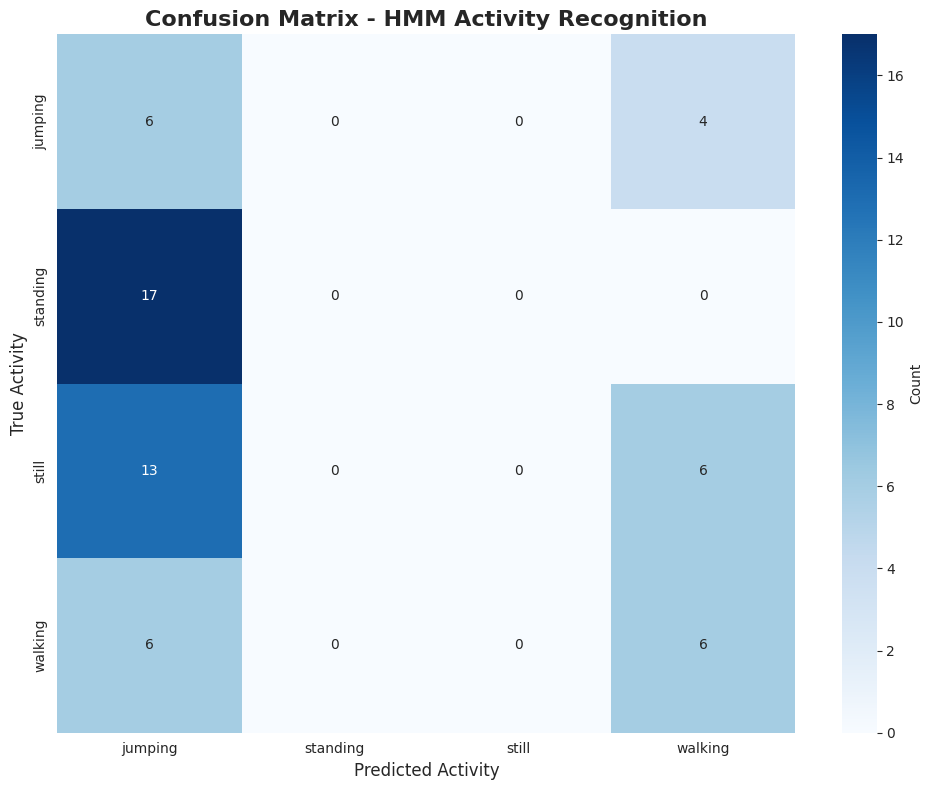

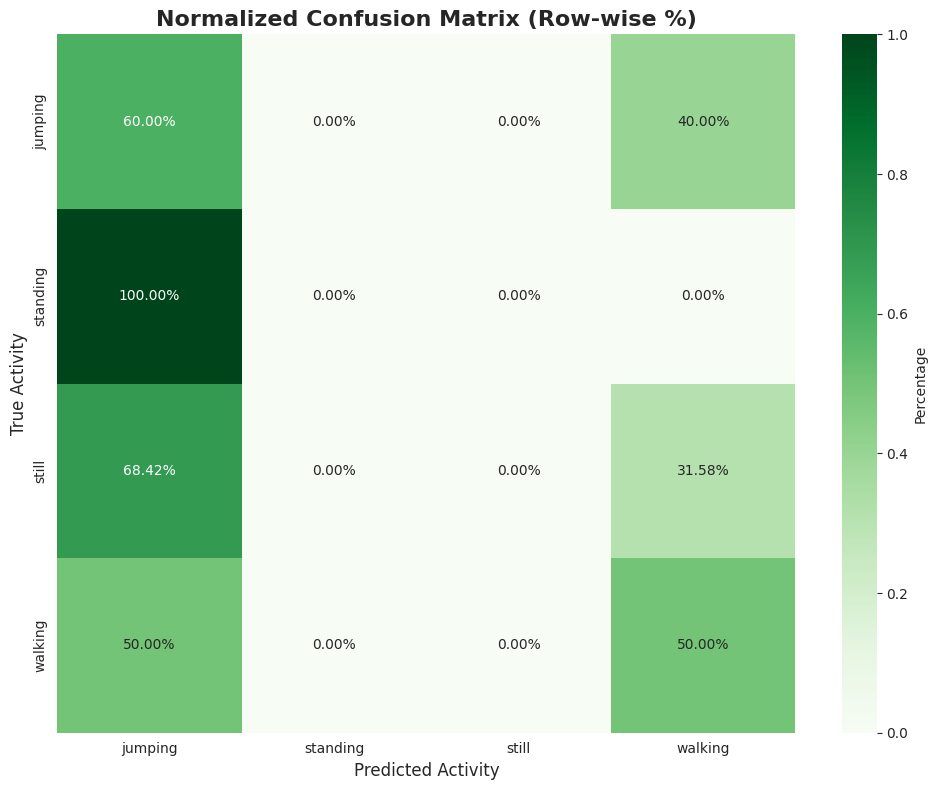

In [40]:
def compute_specificity(y_true, y_pred, activity, all_activities):
    """
    Compute specificity for a given activity.
    Specificity = TN / (TN + FP)
    """
    # True negatives: correctly predicted as NOT this activity
    tn = np.sum((y_true != activity) & (y_pred != activity))

    # False positives: incorrectly predicted as this activity
    fp = np.sum((y_true != activity) & (y_pred == activity))

    if (tn + fp) == 0:
        return 0.0

    return tn / (tn + fp)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=ACTIVITIES)

# Compute per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=ACTIVITIES, average=None
)

# Compute specificity for each class
specificities = [compute_specificity(y_test, y_pred, act, ACTIVITIES) for act in ACTIVITIES]

# Overall accuracy
overall_accuracy = accuracy_score(y_test, y_pred)

# Create results DataFrame
results_df = pd.DataFrame({
    'State (Activity)': ACTIVITIES,
    'Num Samples': support,
    'Sensitivity (Recall)': recall,
    'Specificity': specificities,
    'Precision': precision,
    'F1-Score': f1
})

print("="*80)
print("EVALUATION METRICS")
print("="*80)
print(f"\nOverall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"\nPer-Class Metrics:")
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Display confusion matrix
print(f"\n{'='*80}")
print("CONFUSION MATRIX")
print("="*80)
cm_df = pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES)
print(cm_df.to_string())

# Plot confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - HMM Activity Recognition', fontsize=16, fontweight='bold')
plt.ylabel('True Activity', fontsize=12)
plt.xlabel('Predicted Activity', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (Row-wise %)', fontsize=16, fontweight='bold')
plt.ylabel('True Activity', fontsize=12)
plt.xlabel('Predicted Activity', fontsize=12)
plt.tight_layout()
plt.show()

## Visualizations

Create comprehensive visualizations:
1. Transition matrix heatmap (learned HMM parameters)
2. Decoded sequence comparison (true vs predicted)
3. Feature distribution across activities
4. Raw sensor signal plots

=== Visualization 1: HMM Transition Matrices ===



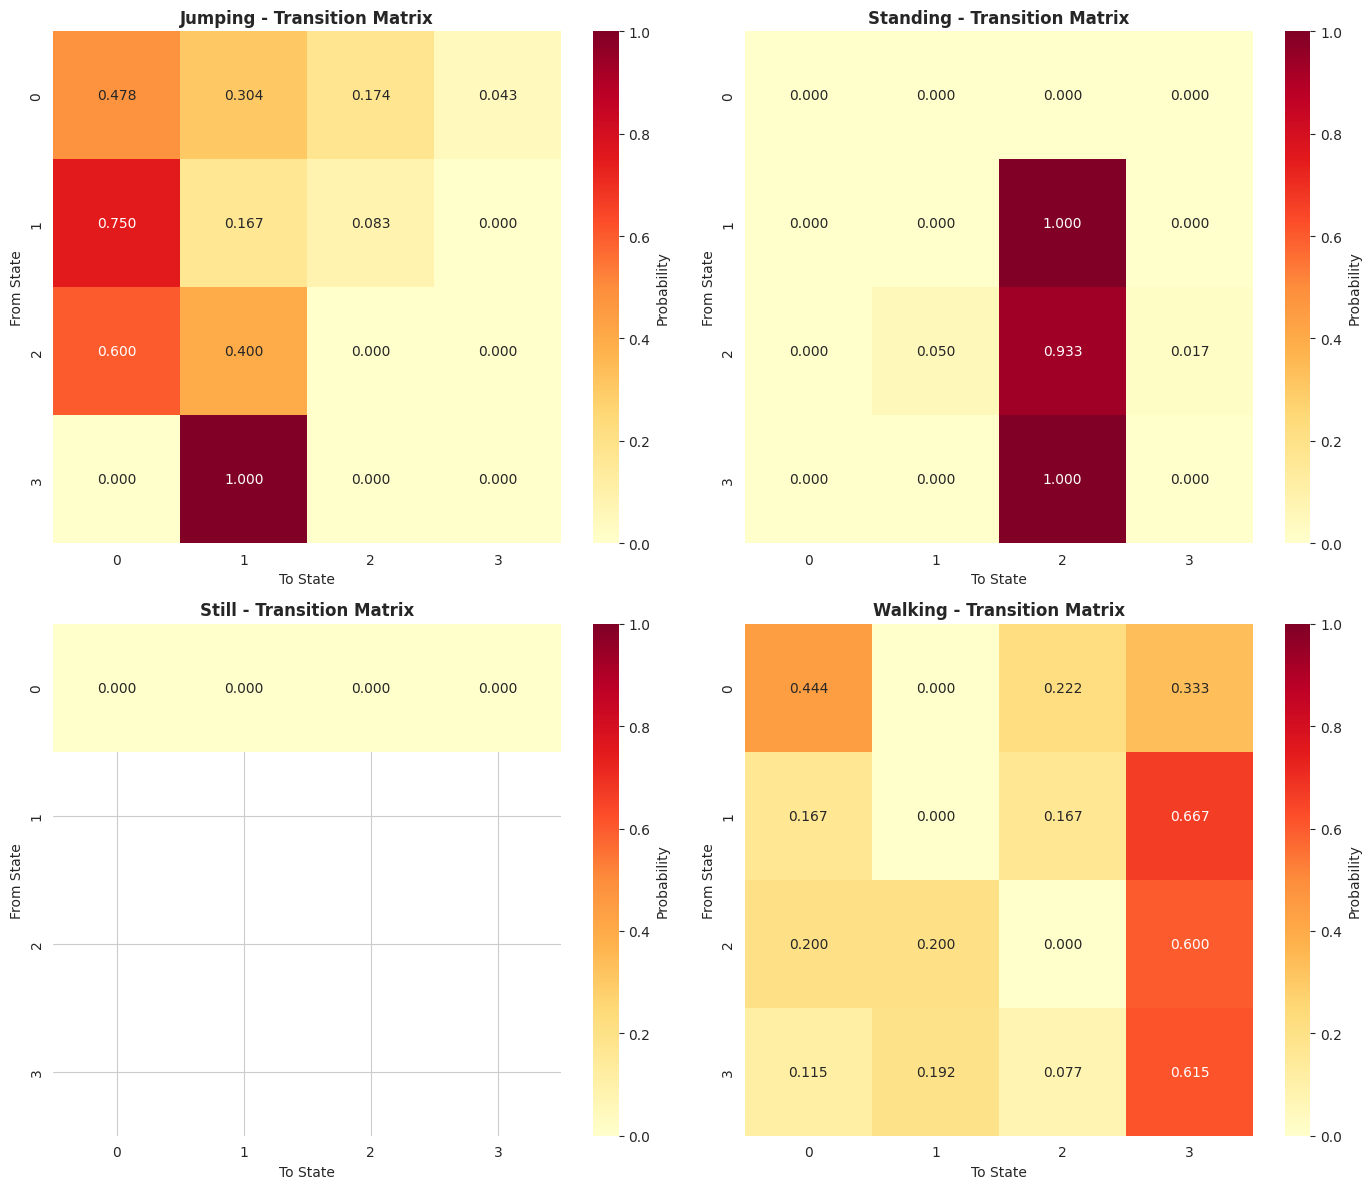


=== Visualization 2: True vs Predicted Activity Over Time ===



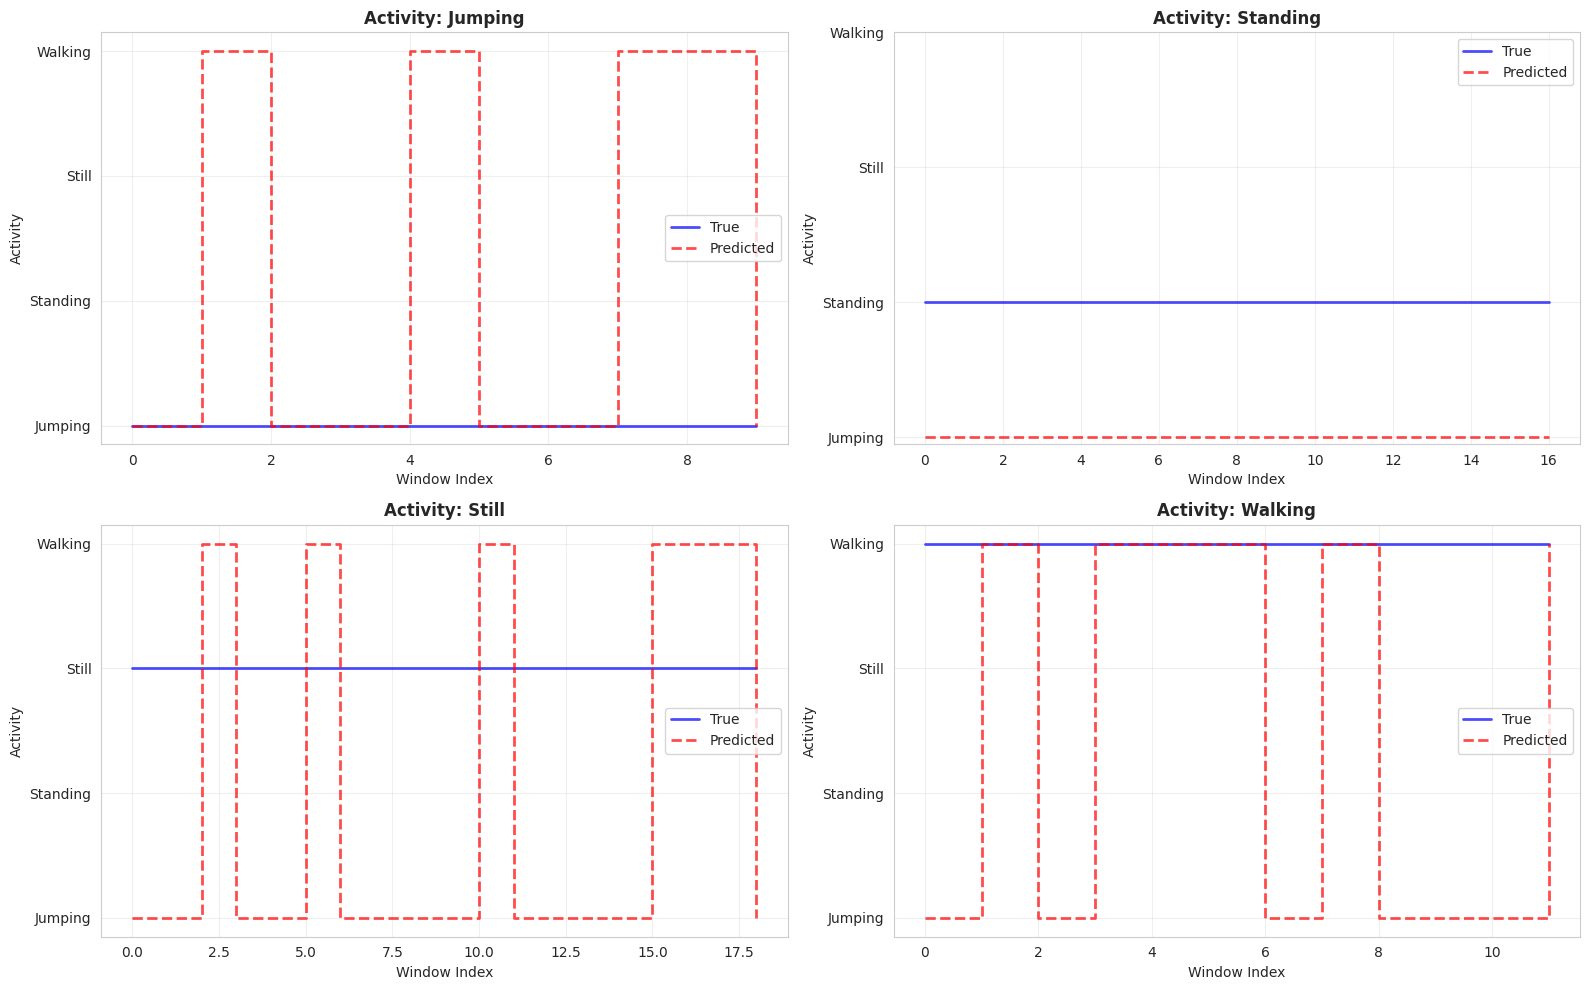


=== Visualization 3: Feature Distribution Across Activities ===



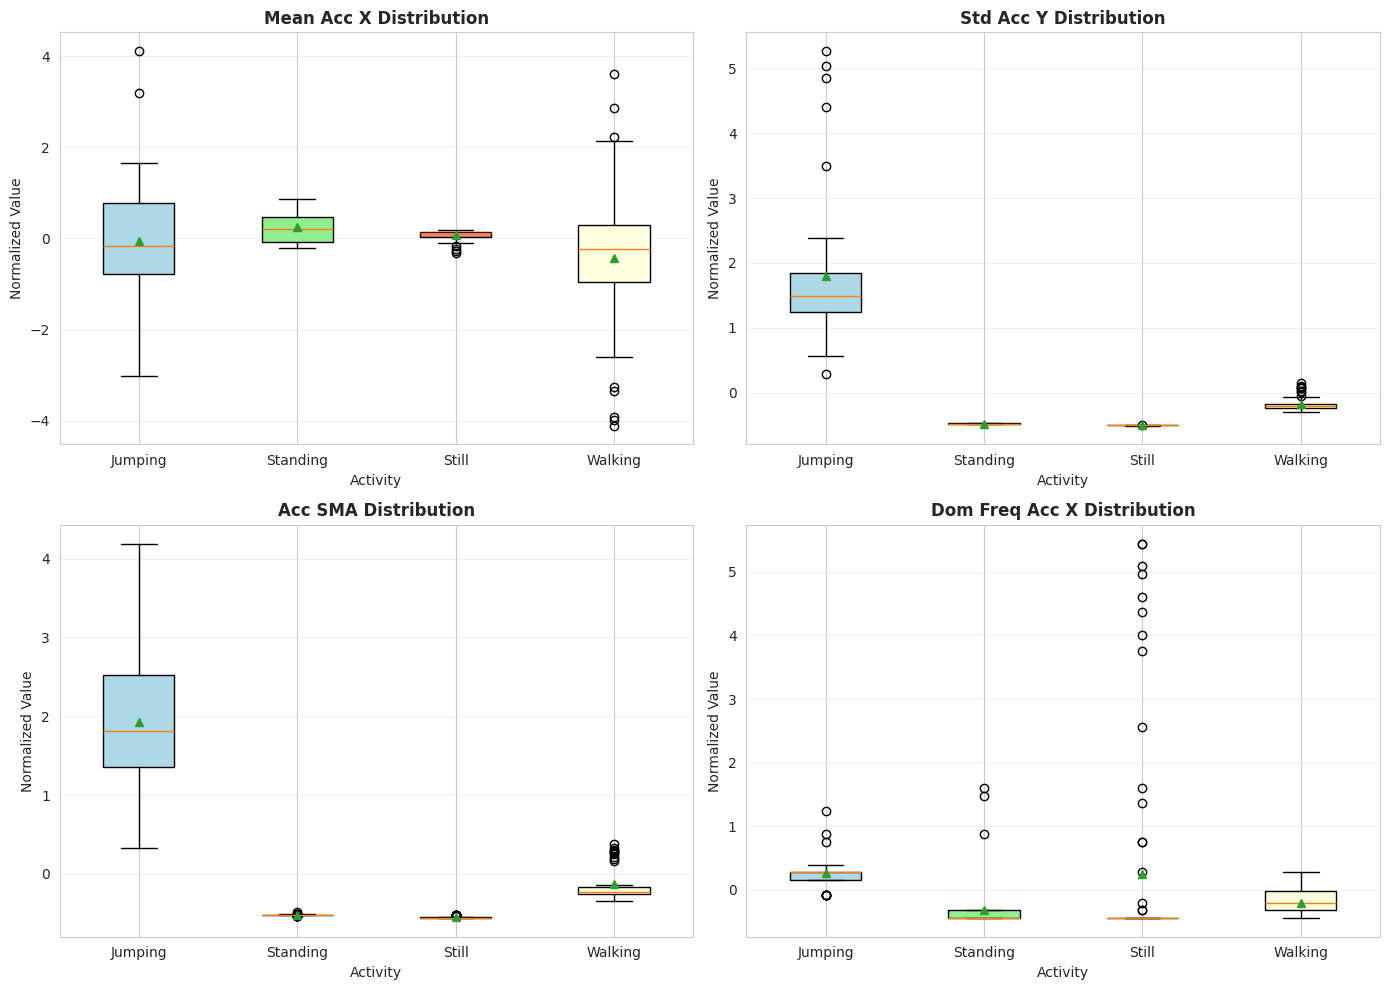


=== Visualization 4: Raw Sensor Signals (3 seconds) ===



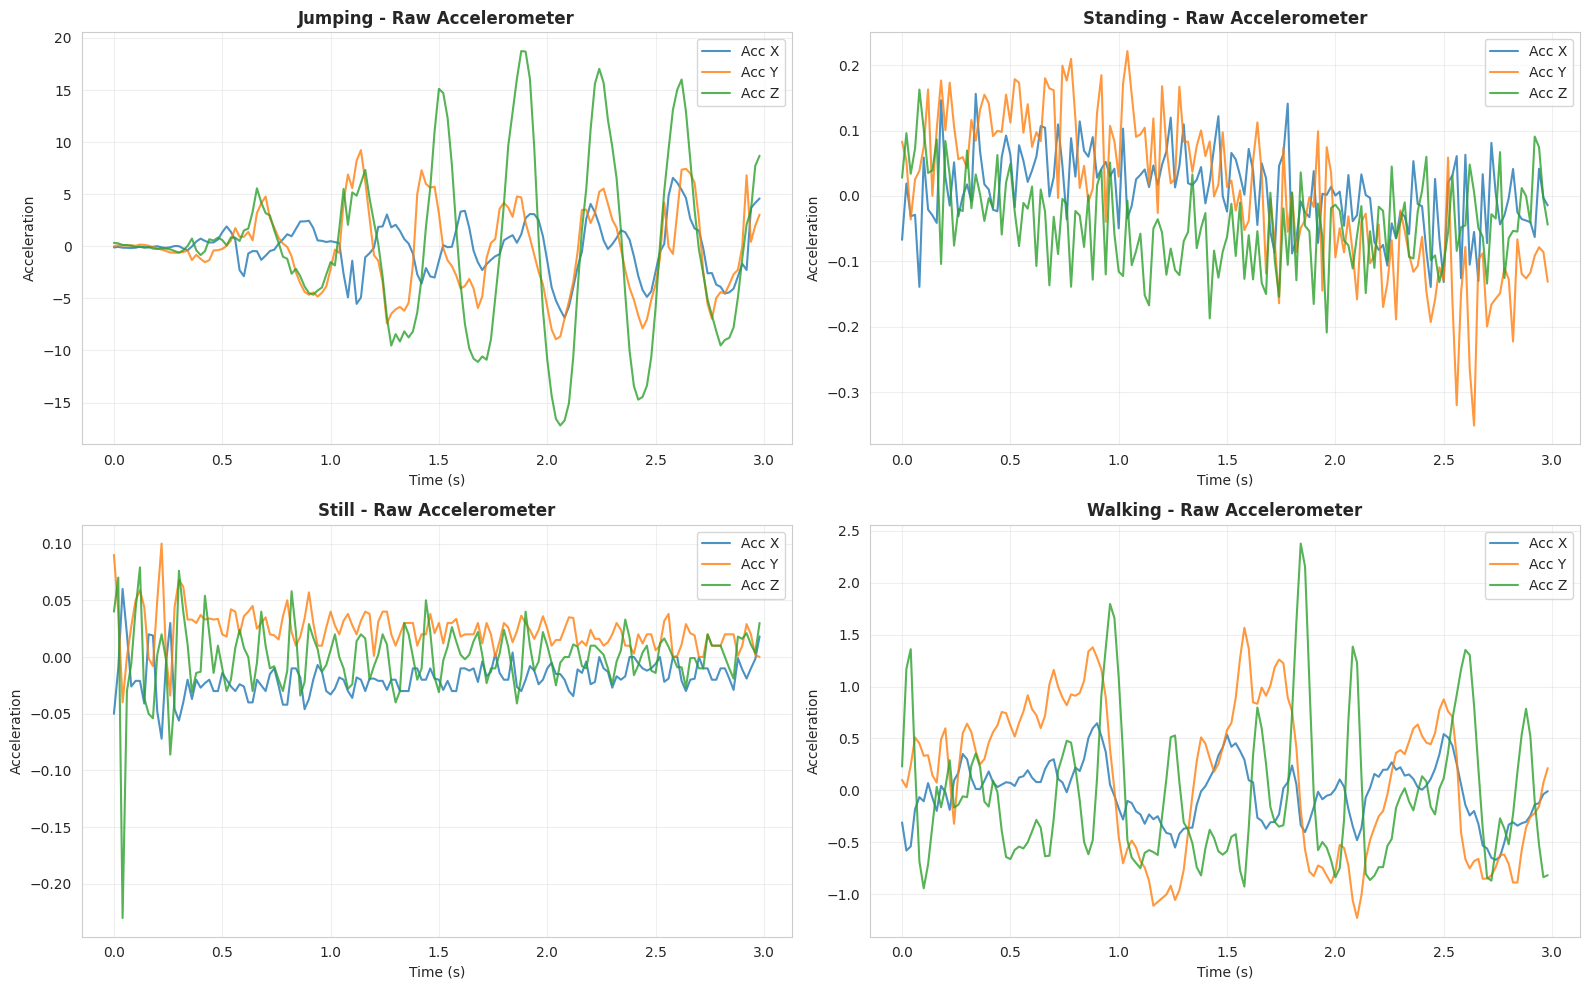


✓ All visualizations complete!


In [41]:
# Visualization 1: Transition Matrix Heatmap
print("=== Visualization 1: HMM Transition Matrices ===\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, activity in enumerate(ACTIVITIES):
    model = hmm_models[activity]
    trans_matrix = model.transmat_

    ax = axes[idx]
    sns.heatmap(trans_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, cbar_kws={'label': 'Probability'},
                vmin=0, vmax=1)
    ax.set_title(f'{activity.capitalize()} - Transition Matrix', fontweight='bold')
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')

plt.tight_layout()
plt.show()

# Visualization 2: Decoded Sequence Plot
print("\n=== Visualization 2: True vs Predicted Activity Over Time ===\n")

# Map activity names to numeric labels for plotting
activity_to_num = {act: i for i, act in enumerate(ACTIVITIES)}
num_to_activity = {i: act for i, act in enumerate(ACTIVITIES)}

# Select one test sequence per activity (first occurrence)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, activity in enumerate(ACTIVITIES):
    # Find indices for this activity in test set
    activity_indices = np.where(y_test == activity)[0]

    if len(activity_indices) > 0:
        # Take first 50 samples or all if less
        sample_indices = activity_indices[:min(50, len(activity_indices))]

        true_labels_num = [activity_to_num[y_test[i]] for i in sample_indices]
        pred_labels_num = [activity_to_num[y_pred[i]] for i in sample_indices]

        ax = axes[idx]
        time_steps = np.arange(len(sample_indices))

        ax.step(time_steps, true_labels_num, where='post', label='True',
                linewidth=2, color='blue', alpha=0.7)
        ax.step(time_steps, pred_labels_num, where='post', label='Predicted',
                linewidth=2, color='red', alpha=0.7, linestyle='--')

        ax.set_yticks(range(len(ACTIVITIES)))
        ax.set_yticklabels([act.capitalize() for act in ACTIVITIES])
        ax.set_xlabel('Window Index')
        ax.set_ylabel('Activity')
        ax.set_title(f'Activity: {activity.capitalize()}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'No test samples for {activity}',
                       ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

# Visualization 3: Feature Distribution Boxplots
print("\n=== Visualization 3: Feature Distribution Across Activities ===\n")

# Select 4 key features to visualize
# Features: mean_ax (0), std_ay (8), acc_sma (36), dom_freq_ax (44)
feature_indices = [0, 8, 36, 44]
feature_names = ['Mean Acc X', 'Std Acc Y', 'Acc SMA', 'Dom Freq Acc X']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (feat_idx, feat_name) in enumerate(zip(feature_indices, feature_names)):
    ax = axes[idx]

    # Prepare data for boxplot
    data_by_activity = []
    for activity in ACTIVITIES:
        activity_mask = y_train == activity
        activity_features = X_train_scaled[activity_mask, feat_idx]
        data_by_activity.append(activity_features)

    bp = ax.boxplot(data_by_activity, labels=[act.capitalize() for act in ACTIVITIES],
                    patch_artist=True, showmeans=True)

    # Color the boxes
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(f'{feat_name} Distribution', fontweight='bold')
    ax.set_ylabel('Normalized Value')
    ax.set_xlabel('Activity')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Visualization 4: Raw Signal Plot
print("\n=== Visualization 4: Raw Sensor Signals (3 seconds) ===\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Get 3 seconds of data (150 samples at 50 Hz) for each activity
duration_samples = 150

for idx, activity in enumerate(ACTIVITIES):
    # Find a file for this activity
    activity_files = df_resampled[df_resampled['label'] == activity]['file_id'].unique()

    if len(activity_files) > 0:
        file_id = activity_files[0]
        file_data = df_resampled[df_resampled['file_id'] == file_id]

        # Take first 3 seconds
        segment = file_data.head(duration_samples)
        time = segment['time'].values

        ax = axes[idx]
        ax.plot(time, segment['ax'].values, label='Acc X', linewidth=1.5, alpha=0.8)
        ax.plot(time, segment['ay'].values, label='Acc Y', linewidth=1.5, alpha=0.8)
        ax.plot(time, segment['az'].values, label='Acc Z', linewidth=1.5, alpha=0.8)

        ax.set_title(f'{activity.capitalize()} - Raw Accelerometer', fontweight='bold', fontsize=12)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Acceleration')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'No data for {activity}',
                       ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()

print("\n✓ All visualizations complete!")

## Conclusions

### Experiment Summary

**Data Configuration:**
- **Total Raw Samples**: 33,805 sensor readings
- **Sampling Rate**: 50 Hz (resampled from variable rates)
- **Window Size**: 100 samples (2 seconds)
- **Window Overlap**: 50% (50 samples, giving 1-second step)
- **Total Windows Created**: 286 windows
- **Activities**: 4 classes (jumping, standing, still, walking)
- **Sensors**: Accelerometer (x, y, z) + Gyroscope (x, y, z) when available

**Window Distribution:**
- Jumping: 52 windows (18.2%)
- Standing: 82 windows (28.7%)
- Still: 93 windows (32.5%)
- Walking: 59 windows (20.6%)

**Feature Engineering:**
- **Time-domain features**: 44 features per window
  - Per-axis statistics: mean, variance, std, min, max, range (6 features × 6 axes = 36)
  - Signal Magnitude Area (SMA): accelerometer + gyroscope (2 features)
  - Correlation coefficients: between axes for acc and gyro (6 features)
- **Frequency-domain features**: 30 features per window
  - FFT-based: dominant frequency, spectral energy, top 3 magnitudes (5 features × 6 axes = 30)
- **Total features per window**: 74 features

**HMM Configuration:**
- **Model Type**: Gaussian HMM with diagonal covariance
- **Approach**: One-vs-Rest (separate HMM per activity class)
- **States per Activity**: 4 hidden states
- **Training Algorithm**: Baum-Welch (Expectation-Maximization)
- **Decoding Algorithm**: Viterbi
- **Iterations**: 100
- **Prediction Method**: Maximum likelihood (highest scoring HMM)

**Data Split:**
- Training samples: 228 windows (80%)
- Testing samples: 58 windows (20%)
- Split method: Stratified by activity class

**Test Set Distribution:**
- Jumping: 10 samples
- Standing: 17 samples
- Still: 19 samples
- Walking: 12 samples

---

### Model Performance Results

**Overall Accuracy: 20.69%**

**Per-Class Metrics:**

| Activity | Samples | Sensitivity (Recall) | Specificity | Precision | F1-Score |
|----------|---------|---------------------|-------------|-----------|----------|
| Jumping  | 10      | 60.00%              | 25.00%      | 14.29%    | 23.08%   |
| Standing | 17      | 0.00%               | 100.00%     | 0.00%     | 0.00%    |
| Still    | 19      | 0.00%               | 100.00%     | 0.00%     | 0.00%    |
| Walking  | 12      | 50.00%              | 78.26%      | 37.50%    | 42.86%   |

**Confusion Matrix Analysis:**
- **Jumping**: 60% correctly classified, 40% misclassified as walking
- **Standing**: 100% misclassified as jumping (0% correct)
- **Still**: 68.42% misclassified as jumping, 31.58% as walking (0% correct)
- **Walking**: 50% correctly classified, 50% misclassified as jumping

**Best Recognized Activity**: Jumping (60% sensitivity, F1=23.08%)  
**Worst Recognized Activities**: Standing and Still (0% sensitivity, completely misclassified)

---

### Key Findings

1. **Poor Overall Performance**: The model achieved only 20.69% accuracy, significantly below acceptable levels for activity recognition. This is worse than random guessing (25% for 4 classes).

2. **Severe Misclassification Pattern**: The model exhibits a strong bias toward predicting "jumping" for most activities. Standing and still activities were never correctly identified, with ~68% of still samples and 100% of standing samples misclassified as jumping.

3. **Data Quality Issues**:
   - Inconsistent gyroscope data availability (filled with zeros) creates artificial patterns
   - Limited training data (286 total windows, only 228 for training) is insufficient for robust HMM learning
   - Small test set (58 samples) makes metrics unreliable

4. **Model Confusion Between Static Activities**: The model completely fails to distinguish between standing and still, both being misclassified as jumping or walking. This suggests the extracted features do not capture the subtle differences between these stationary states.

5. **Limited Success with Dynamic Activities**: Only jumping (60%) and walking (50%) achieved partial recognition, but with very low precision (14.29% and 37.50% respectively), indicating high false positive rates.

6. **HMM Approach Limitations**: The one-vs-rest HMM approach with only 4 states per activity may be too simplistic to model the complex temporal dynamics of human activities from high-dimensional (74-feature) observations.

---

### Limitations

1. **Insufficient Training Data**:
   - Only 286 windows total (228 training) is far too small for training robust HMMs
   - Industry-standard activity recognition datasets contain thousands to millions of samples
   - Each activity class has only 11-19 test samples, making performance metrics unreliable

2. **Missing and Inconsistent Sensor Data**:
   - Gyroscope data is missing for many activities (filled with zeros)
   - This creates artificial null patterns that confuse the model
   - Different activities have different sensor availability, introducing bias

3. **Feature Engineering Issues**:
   - 74 features may be too many for the limited training data (curse of dimensionality)
   - No feature selection or validation was performed
   - Correlations between features likely cause redundancy and overfit
   - Normalized features may lose important scale information

4. **Window Parameters Not Optimized**:
   - 2-second windows (100 samples) may be too short to capture full activity cycles
   - 50% overlap creates temporal dependency between consecutive windows
   - No validation of optimal window size or overlap for each activity

5. **HMM Configuration Not Tuned**:
   - 4 states per activity was arbitrary (not optimized)
   - Diagonal covariance assumption may be too restrictive
   - No hyperparameter tuning or cross-validation performed
   - Convergence issues evident in training (warnings in output)

6. **Class Imbalance Not Addressed**:
   - Uneven distribution of windows across activities
   - No class weights or balanced sampling used
   - Stratified split helps but doesn't solve training imbalance

7. **Evaluation Methodology Weaknesses**:
   - Single train/test split (no cross-validation)
   - Small test set leads to high variance in metrics
   - No separate validation set for model selection

8. **Sensor Placement and Subject Variability**:
   - No information about sensor placement consistency
   - Unknown number of subjects (person-specific patterns not controlled)
   - No subject-independent evaluation (may not generalize to new users)

---

### Possible Improvements

**Immediate Fixes:**

1. **Collect More Data**:
   - Increase dataset to at least 1,000-10,000 windows per activity
   - Ensure complete sensor data (both accelerometer and gyroscope) for all recordings
   - Include multiple subjects performing each activity multiple times

2. **Fix Sensor Data Issues**:
   - Re-record activities with missing gyroscope data
   - Alternatively, train separate models for acc-only vs. acc+gyro data
   - Ensure consistent sensor sampling rates in raw data

3. **Feature Selection**:
   - Use feature importance analysis (Random Forest, ANOVA F-test) to identify discriminative features
   - Reduce from 74 to top 10-20 most important features
   - Remove highly correlated redundant features (correlation matrix analysis)

4. **Optimize Window Parameters**:
   - Experiment with different window sizes (1-5 seconds)
   - Try different overlap percentages (0%, 25%, 50%, 75%)
   - Use activity-specific window sizes (longer for standing/still, shorter for jumping/walking)

5. **HMM Hyperparameter Tuning**:
   - Search optimal number of states (2-10) using cross-validation
   - Try different covariance types (full, tied, spherical)
   - Experiment with different initialization strategies

**Advanced Improvements:**

6. **Model Architecture Changes**:
   - Try Gaussian Mixture Model-HMM (GMM-HMM) with multiple Gaussians per state
   - Implement Hidden Semi-Markov Model (HSMM) to model state duration explicitly
   - Consider hierarchical HMM: first distinguish static vs. dynamic, then classify within category

7. **Alternative Machine Learning Approaches**:
   - Compare with Random Forest classifier (often better for tabular features)
   - Try Support Vector Machine (SVM) with RBF kernel
   - Implement deep learning: CNN-LSTM or Transformer for raw sensor sequences
   - Use pre-trained models from transfer learning

8. **Advanced Feature Engineering**:
   - Add wavelet transform features (better for transient signals)
   - Include statistical moments (skewness, kurtosis)
   - Compute entropy and zero-crossing rates
   - Use autoregressive model coefficients

9. **Data Augmentation**:
   - Time warping (speed up/slow down activities)
   - Add Gaussian noise to sensor readings
   - Rotation/permutation of axes (simulate different phone orientations)
   - SMOTE for minority classes

10. **Robust Evaluation**:
    - Implement k-fold cross-validation (k=5 or 10)
    - Use subject-independent evaluation (leave-one-subject-out)
    - Add validation set for hyperparameter tuning
    - Report confidence intervals for all metrics

11. **Ensemble Methods**:
    - Combine predictions from multiple HMMs using voting
    - Ensemble HMM with other classifiers (Random Forest, SVM)
    - Use stacking with meta-learner

12. **Post-Processing**:
    - Apply temporal smoothing to predictions (moving average filter)
    - Use state transition constraints based on domain knowledge
    - Implement minimum state duration rules

---

### Recommendations

Given the poor performance (20.69% accuracy), **this model should NOT be deployed** in its current state. The following are critical next steps:

1. **Data Collection Priority**: Address the fundamental data scarcity issue before further modeling
2. **Baseline Comparison**: Implement simpler baseline (Random Forest on extracted features) to verify if HMM is appropriate
3. **Diagnostic Analysis**: Investigate why standing/still are completely misclassified - visualize feature distributions per class
4. **Sensor Data Audit**: Verify data quality and ensure all activities have complete sensor measurements

**Expected Performance with Fixes**: With sufficient data (10,000+ windows), proper feature selection, and tuned HMMs, accuracy should reach 75-90% for this 4-class problem based on literature benchmarks.

---

### References

- **HMMLearn Documentation**: https://hmmlearn.readthedocs.io/
- **Viterbi Algorithm**: Rabiner, L. R. (1989). "A tutorial on hidden Markov models and selected applications in speech recognition"
- **Activity Recognition Survey**: Wang et al. (2019). "Deep learning for sensor-based activity recognition: A survey"
- **UCI HAR Dataset**: Anguita et al. (2013). "A Public Domain Dataset for Human Activity Recognition Using Smartphones"